In [1]:
!pip install yfinance torch --quiet

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import yfinance as yf


In [2]:
class LSTMModel(nn.Module):
    def __init__(self, n_features, hidden=64):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, batch_first=True)
        self.fc = nn.Linear(hidden, n_features)

    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.fc(h[-1])


In [3]:
def create_sequences(data, window=30):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i])
        y.append(data[i])
    return np.array(X), np.array(y)


In [4]:
tickers = ["RELIANCE.NS", "TCS.NS", "INFY.NS"]


[*********************100%***********************]  1 of 1 completed


LSTM MODEL FOR RELIANCE.NS
EDA for RELIANCE.NS started.

--- BASIC INFO ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3956 entries, 2010-01-04 to 2026-01-07
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   (Open, RELIANCE.NS)    3956 non-null   float64
 1   (High, RELIANCE.NS)    3956 non-null   float64
 2   (Low, RELIANCE.NS)     3956 non-null   float64
 3   (Close, RELIANCE.NS)   3956 non-null   float64
 4   (Volume, RELIANCE.NS)  3956 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 185.4 KB
None

--- FIRST 5 ROWS ---


Price,Open,High,Low,Close,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2010-01-04,221.763796,221.763796,207.688886,218.593124,76646086
2010-01-05,233.714724,233.714724,216.540267,217.617477,21392825
2010-01-06,219.487382,222.454812,217.607339,221.133698,23691760
2010-01-07,221.133708,226.621393,219.101219,224.802322,26197920
2010-01-08,225.198672,226.377517,222.759699,224.212921,15110149



--- LAST 5 ROWS ---


Price,Open,High,Low,Close,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2026-01-01,1573.699951,1592.500000,1571.099976,1575.599976,6408128
2026-01-02,1580.000000,1594.599976,1578.199951,1592.300049,6602230
2026-01-05,1593.000000,1611.800049,1575.300049,1578.099976,8704973
2026-01-06,1569.000000,1569.000000,1496.300049,1507.599976,27417125
2026-01-07,1510.000000,1520.000000,1498.000000,1504.199951,11197613



--- MISSING VALUES ---
Price   Ticker     
Open    RELIANCE.NS    0
High    RELIANCE.NS    0
Low     RELIANCE.NS    0
Close   RELIANCE.NS    0
Volume  RELIANCE.NS    0
dtype: int64


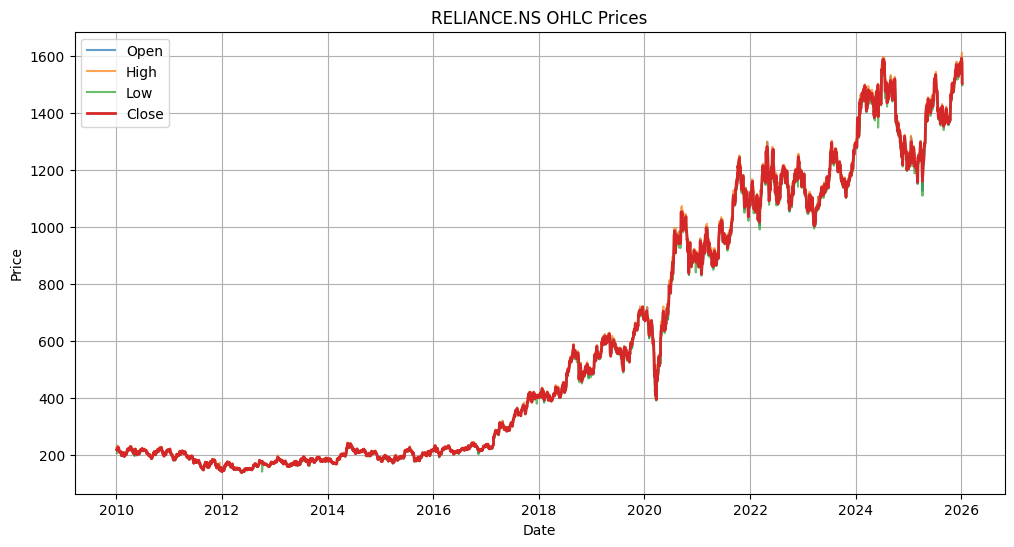

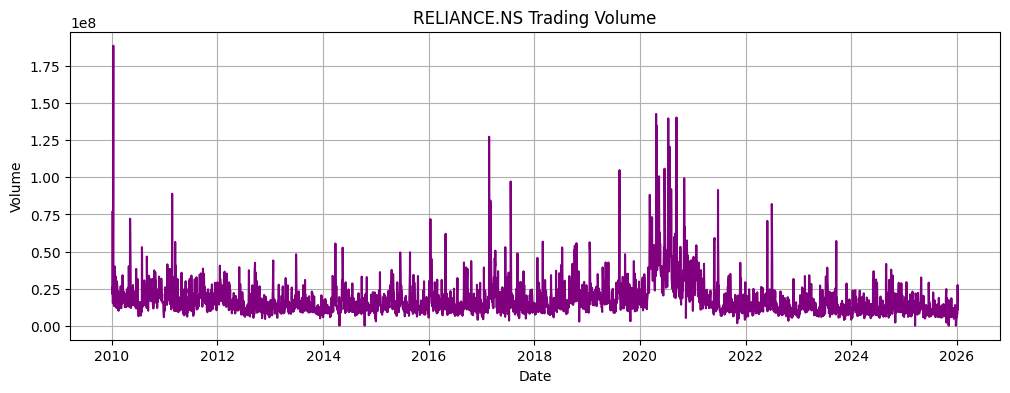

<Figure size 600x400 with 0 Axes>

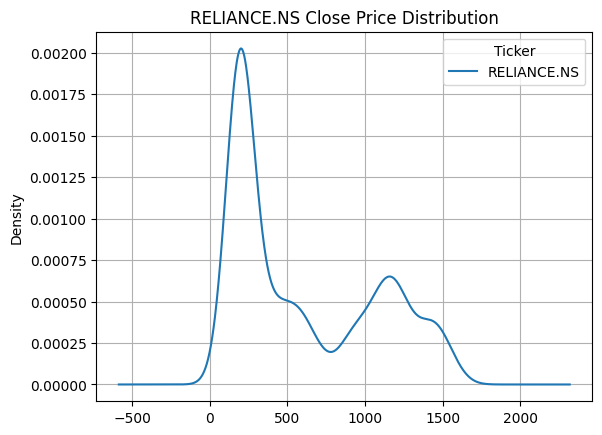

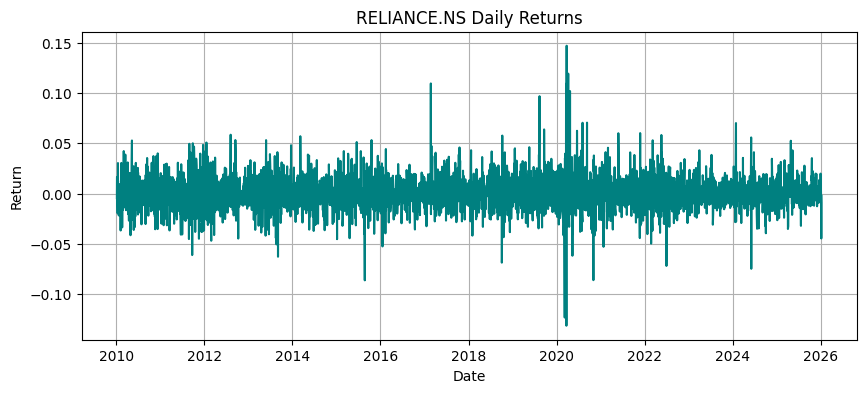

EDA completed for RELIANCE.NS. Proceeding to model training...
Epoch 0, Loss: 0.23065218329429626
Epoch 5, Loss: 0.1782960593700409
Epoch 10, Loss: 0.12352841347455978
Epoch 15, Loss: 0.056920357048511505
RMSE: 0.1348936606076311
MAE: 0.10952682793140411
R2: -7.635480880737305
Directional Accuracy: 1.0


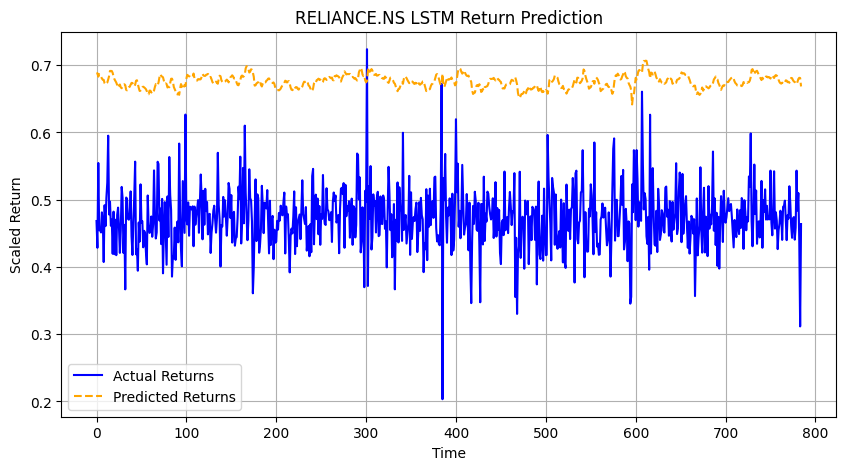


LSTM MODEL FOR TCS.NS


[*********************100%***********************]  1 of 1 completed

EDA for TCS.NS started.

--- BASIC INFO ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3956 entries, 2010-01-04 to 2026-01-07
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   (Open, TCS.NS)    3956 non-null   float64
 1   (High, TCS.NS)    3956 non-null   float64
 2   (Low, TCS.NS)     3956 non-null   float64
 3   (Close, TCS.NS)   3956 non-null   float64
 4   (Volume, TCS.NS)  3956 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 185.4 KB
None

--- FIRST 5 ROWS ---


Price,Open,High,Low,Close,Volume
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
Date,,,,,
2010-01-04,268.672597,270.132013,266.625873,267.551361,1963682
2010-01-05,268.743847,270.363425,265.736047,267.622589,2014488
2010-01-06,267.622504,267.747100,260.912817,261.571320,3349176
2010-01-07,261.802771,263.190993,253.081945,254.292191,6474892
2010-01-08,254.861611,255.751491,247.920547,249.095184,6048178



--- LAST 5 ROWS ---


Price,Open,High,Low,Close,Volume
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
Date,,,,,
2026-01-01,3215.000000,3234.100098,3198.199951,3227.399902,1255735
2026-01-02,3234.000000,3254.300049,3219.500000,3250.699951,1184324
2026-01-05,3240.500000,3247.000000,3191.000000,3216.100098,2341703
2026-01-06,3210.000000,3263.199951,3205.000000,3255.800049,2912325
2026-01-07,3242.899902,3300.600098,3223.199951,3295.600098,1989207



--- MISSING VALUES ---
Price   Ticker
Open    TCS.NS    0
High    TCS.NS    0
Low     TCS.NS    0
Close   TCS.NS    0
Volume  TCS.NS    0
dtype: int64


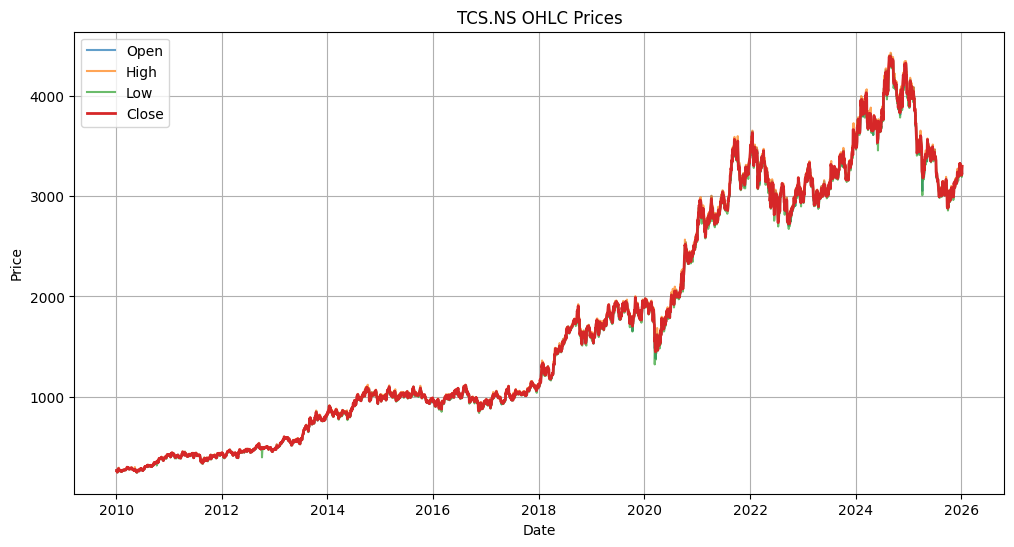

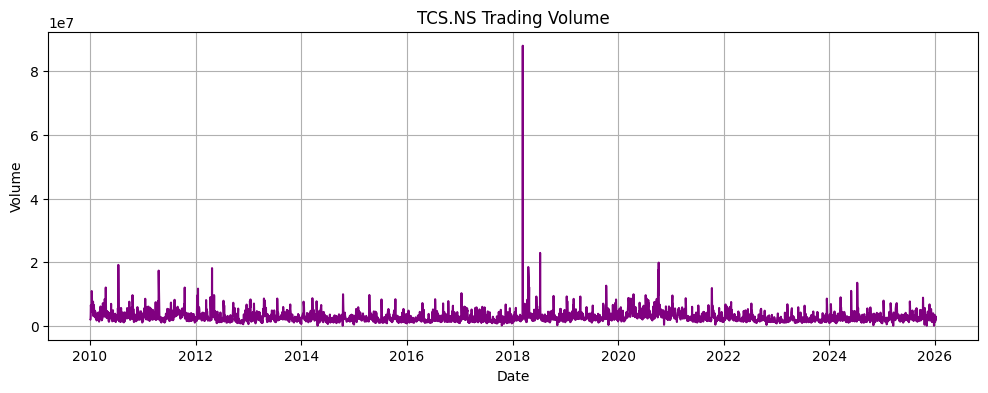

<Figure size 600x400 with 0 Axes>

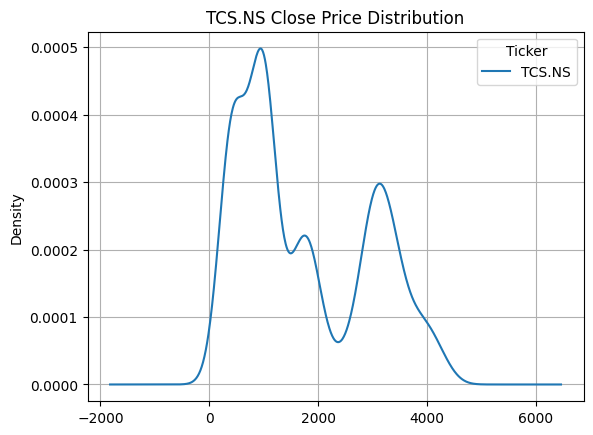

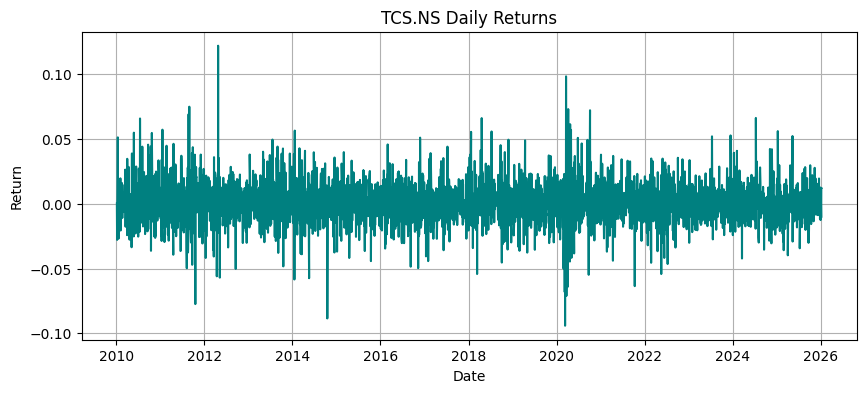

EDA completed for TCS.NS. Proceeding to model training...
Epoch 0, Loss: 0.21452341973781586
Epoch 5, Loss: 0.16059988737106323
Epoch 10, Loss: 0.09699273854494095
Epoch 15, Loss: 0.025346236303448677
RMSE: 0.15042200628068664
MAE: 0.1322702318429947
R2: -15.909510612487793
Directional Accuracy: 1.0


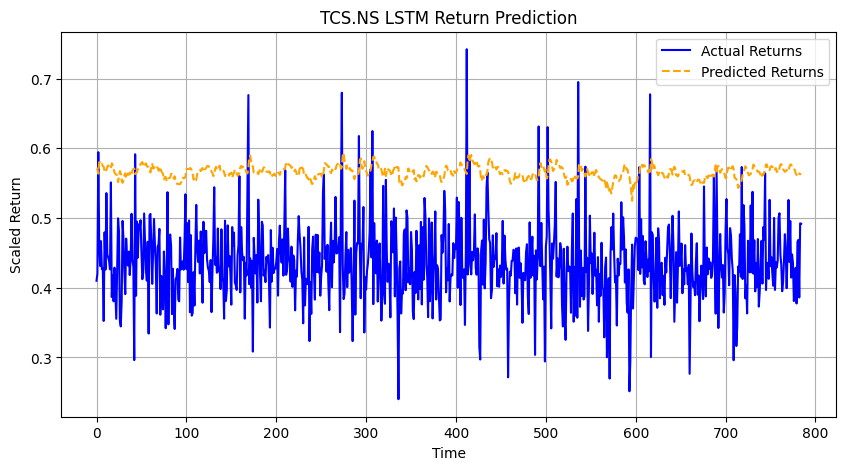


LSTM MODEL FOR INFY.NS


[*********************100%***********************]  1 of 1 completed

EDA for INFY.NS started.

--- BASIC INFO ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3956 entries, 2010-01-04 to 2026-01-07
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Open, INFY.NS)    3956 non-null   float64
 1   (High, INFY.NS)    3956 non-null   float64
 2   (Low, INFY.NS)     3956 non-null   float64
 3   (Close, INFY.NS)   3956 non-null   float64
 4   (Volume, INFY.NS)  3956 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 185.4 KB
None

--- FIRST 5 ROWS ---


Price,Open,High,Low,Close,Volume
Ticker,INFY.NS,INFY.NS,INFY.NS,INFY.NS,INFY.NS
Date,,,,,
2010-01-04,221.957367,223.658190,220.707266,222.178482,4069264
2010-01-05,222.807778,223.717714,221.115468,222.922592,6895528
2010-01-06,228.165466,228.165466,218.989531,219.669861,6817288
2010-01-07,219.967488,219.967488,214.150660,214.733200,10892600
2010-01-08,214.218732,214.584414,209.031221,209.558472,12649312



--- LAST 5 ROWS ---


Price,Open,High,Low,Close,Volume
Ticker,INFY.NS,INFY.NS,INFY.NS,INFY.NS,INFY.NS
Date,,,,,
2026-01-01,1615.400024,1639.599976,1614.099976,1629.800049,3658165
2026-01-02,1635.900024,1643.500000,1627.500000,1640.400024,2524526
2026-01-05,1637.000000,1637.000000,1583.099976,1606.400024,5917885
2026-01-06,1600.099976,1619.900024,1599.000000,1612.199951,4466729
2026-01-07,1615.000000,1642.000000,1615.000000,1639.000000,4507485



--- MISSING VALUES ---
Price   Ticker 
Open    INFY.NS    0
High    INFY.NS    0
Low     INFY.NS    0
Close   INFY.NS    0
Volume  INFY.NS    0
dtype: int64


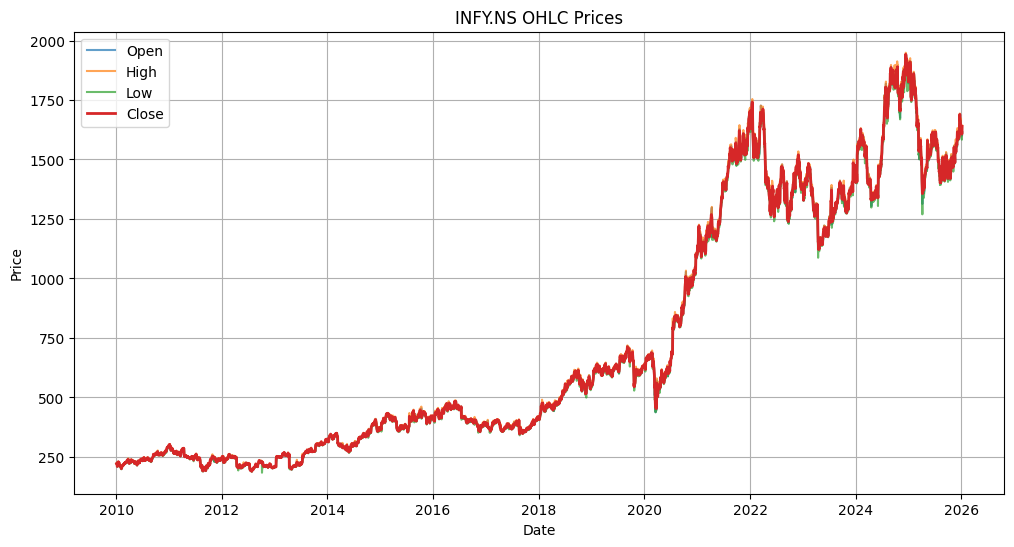

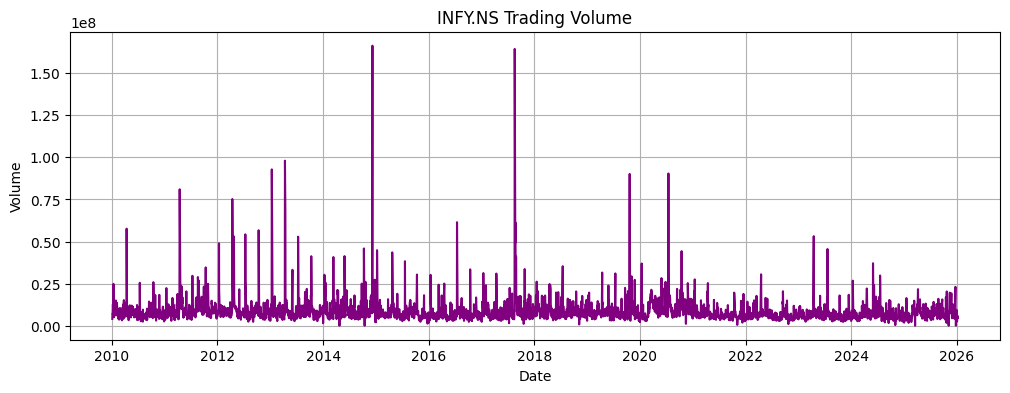

<Figure size 600x400 with 0 Axes>

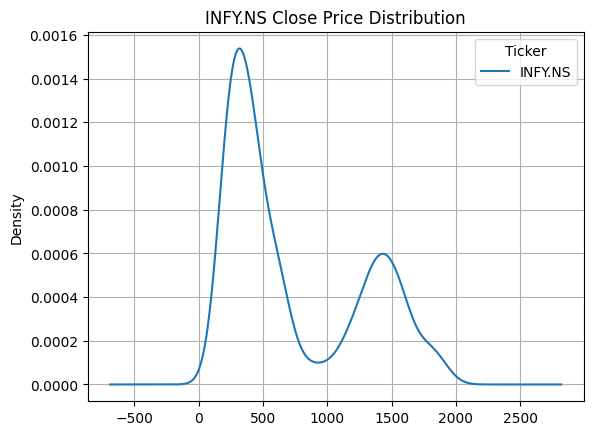

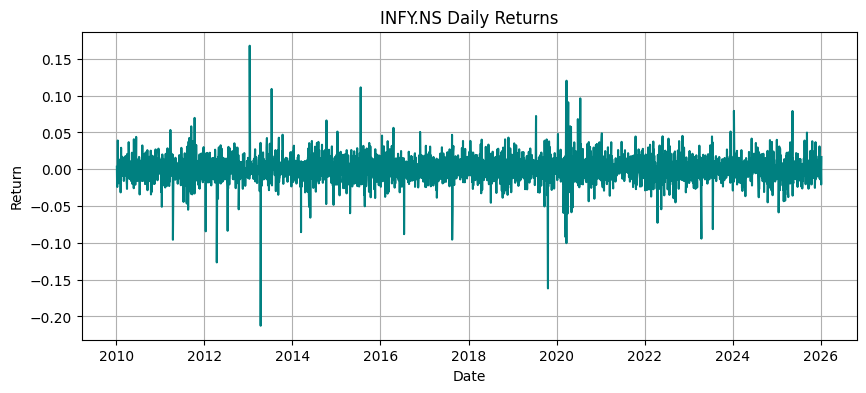

EDA completed for INFY.NS. Proceeding to model training...
Epoch 0, Loss: 0.2638320326805115
Epoch 5, Loss: 0.20301507413387299
Epoch 10, Loss: 0.14135119318962097
Epoch 15, Loss: 0.06953417509794235
RMSE: 0.13174371672799595
MAE: 0.11295104771852493
R2: -8.543185234069824
Directional Accuracy: 1.0


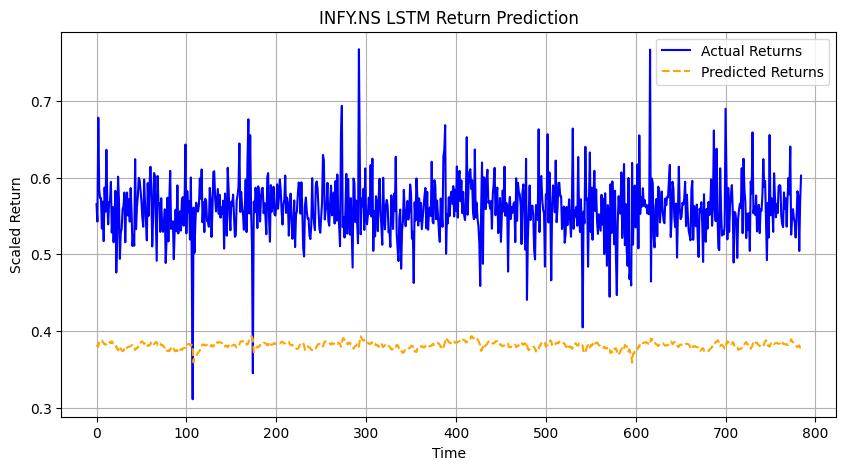

In [7]:
for ticker in tickers:

    print("\n" + "="*60)
    print(f"LSTM MODEL FOR {ticker}")
    print("="*60)

    # -----------------------------
    # Data Download
    # -----------------------------
    df = yf.download(ticker, start="2010-01-01")
    df = df[['Open','High','Low','Close','Volume']]
    df.dropna(inplace=True)
    
    
    print(f"EDA for {ticker} started.")
    
    
    print("\n--- BASIC INFO ---")
    print(df.info())

    print("\n--- FIRST 5 ROWS ---")
    display(df.head())

    print("\n--- LAST 5 ROWS ---")
    display(df.tail())
    
    print("\n--- MISSING VALUES ---")
    print(df.isnull().sum())
    
    df = df.dropna()

    
    plt.figure(figsize=(12,6))
    plt.plot(df['Open'], label='Open', alpha=0.7)
    plt.plot(df['High'], label='High', alpha=0.7)
    plt.plot(df['Low'], label='Low', alpha=0.7)
    plt.plot(df['Close'], label='Close', linewidth=2)
    plt.title(f"{ticker} OHLC Prices")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True)
    plt.show()
    
    plt.figure(figsize=(12,4))
    plt.plot(df['Volume'], color='purple')
    plt.title(f"{ticker} Trading Volume")
    plt.xlabel("Date")
    plt.ylabel("Volume")
    plt.grid(True)
    plt.show()
    
    plt.figure(figsize=(6,4))
    df['Close'].plot(kind='kde')
    plt.title(f"{ticker} Close Price Distribution")
    plt.grid(True)
    plt.show()
    
    returns = df['Close'].pct_change().dropna()

    plt.figure(figsize=(10,4))
    plt.plot(returns, color='teal')
    plt.title(f"{ticker} Daily Returns")
    plt.xlabel("Date")
    plt.ylabel("Return")
    plt.grid(True)
    plt.show()

    print(f"EDA completed for {ticker}. Proceeding to model training...")
    df = df[['Open','High','Low','Close']]

    # -----------------------------
    # Return-based preprocessing (AS IN YOUR CODE)
    # -----------------------------
    returns = df.pct_change().dropna()

    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(returns)

    # -----------------------------
    # Create sequences
    # -----------------------------
    X, y = create_sequences(scaled, window=30)

    X = torch.tensor(X, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.float32)

    # -----------------------------
    # Train-Test Split
    # -----------------------------
    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # -----------------------------
    # Model + Training (UNCHANGED)
    # -----------------------------
    model = LSTMModel(X.shape[2])
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(20):
        optimizer.zero_grad()
        preds = model(X_train)
        loss = criterion(preds, y_train)
        loss.backward()
        optimizer.step()

        if epoch % 5 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item()}")

    # -----------------------------
    # Evaluation
    # -----------------------------
    model.eval()
    with torch.no_grad():
        preds = model(X_test).numpy()
        actual = y_test.numpy()

    rmse = np.sqrt(mean_squared_error(actual, preds))
    mae = mean_absolute_error(actual, preds)
    r2 = r2_score(actual, preds)

    directional_accuracy = np.mean(
        np.sign(actual) == np.sign(preds)
    )

    print("RMSE:", rmse)
    print("MAE:", mae)
    print("R2:", r2)
    print("Directional Accuracy:", directional_accuracy)

    # -----------------------------
    # PLOT (ARIMA-STYLE, CLEAN)
    # -----------------------------
    # Plot only CLOSE return (index 3)
    plt.figure(figsize=(10,5))
    plt.plot(
        actual[:,3],
        label="Actual Returns",
        color="blue"
    )
    plt.plot(
        preds[:,3],
        label="Predicted Returns",
        color="orange",
        linestyle="--"
    )
    plt.title(f"{ticker} LSTM Return Prediction")
    plt.xlabel("Time")
    plt.ylabel("Scaled Return")
    plt.legend()
    plt.grid(True)
    plt.show()
